# Imports and utils

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

In [ ]:
if 'google.colab' in str(get_ipython()): # running in colab
    !git clone --config lfs.fetchinclude="*"  https://github.com/sinc-lab/xvalRNAfolding.git
    DATA_PATH = './xvalRNAfolding/'
else:
    DATA_PATH = '../'

# Falta subir a drive los summaries pkl <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# Falta sacar los números de los directorios dentro de data y results

In [ ]:
# style globals
marker_colors = ["#6A6AFA", "#6262F8", "#2929FB", "#0000FF",
                 "#FF746C", "#FC5141", "#FF2727", "#ED2100", "#FD0A0A", "#D20E00"]
mmarkers = ['o', 's', 'D', 'P', '^', 'v', 'X', 'd', '<', '>']
marker_sizes = 0.1 * np.array([35, 30, 30, 45, 50, 50, 50, 50, 50, 50]) # adjusted for smaller figures

strip_colors = sns.color_palette("tab10") # n_colors=Nfolds just remove the last 10-Nfolds colors
nshift = 8
strip_colors = strip_colors[nshift:] + strip_colors[:nshift]

font_size = 6 # max 7

plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.minor.width'] = 0.4
plt.rcParams['ytick.minor.width'] = 0.4
plt.rcParams['xtick.major.size'] = 2.5
plt.rcParams['ytick.major.size'] = 2.5

In [ ]:
def strip_folds(summary, splits, x_, hue_, fig_size, marker_colors, strip_colors, strip_alpha=0.2, include_legend=False, fam_order=None):

    if fig_size == "1col":
        fig_width1col = 3.22
    elif fig_size == "2col":
        fig_width1col = 6.75
    elif fig_size == "2in2col":
        fig_width1col = 6.75/2
    elif fig_size == "3in2col":
        fig_width1col = 6.75/3
    elif fig_size == "2x3in2col":
        fig_width1col = 6.75/3*2 * 1.1
    else:
        fig_width1col = 3.22
        print("fig_size not recognized, using 1col size")
    fig_height = 2.0

    fig, ax = plt.subplots(figsize=(fig_width1col, fig_height), dpi=150)
    plt.rcParams.update({'font.size': font_size})
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)

    if fam_order is None:
      test = splits.loc[splits['partition']=='test'].groupby(['fold_number']).count()
      train = splits.loc[splits['partition']=='train'].groupby(['fold_number']).count()
    else:
      test = splits.loc[splits['partition']=='test'].groupby(['fold_name']).count()
      train = splits.loc[splits['partition']=='train'].groupby(['fold_name']).count()
    tt = (test/(test+train))

    sns.stripplot(
        data=summary, x= x_, y='f1', hue= hue_,
        dodge=True, #palette=palette,
        jitter=0.25, alpha=0.15, size=2,
        order=fam_order,
        zorder=1,
        legend=False,
    )

    # recolor strips so all points from the same fold share the same color
    for coll in ax.collections:
        offsets = coll.get_offsets()
        if offsets is None or len(offsets) == 0:
            continue

        x_vals = np.asarray(offsets)[:, 0]
        fold_idx = np.rint(x_vals).astype(int)
        fold_idx = np.mod(fold_idx, len(strip_colors))

        colors = [strip_colors[i] for i in fold_idx]
        coll.set_facecolors(colors)
        coll.set_edgecolors(colors)
        coll.set_alpha(strip_alpha)


    # avoid duplicate legend handling (legend is managed later in the function)
    if ax.legend_ is not None:
        ax.legend_.remove()

    methods = summary.method.unique()
    n_methods = len(methods)
    for i, method in enumerate(methods):
        medians = summary[summary["method"] == method].groupby("fold")["f1"].median().reset_index()
        if fam_order is not None:
            original_order = list(summary.family.unique())
            medians_copy = medians.copy()
            for j, fam in enumerate(fam_order):
                mf1 = medians_copy.loc[medians_copy['fold'] == original_order.index(fam), 'f1'].values[0]
                medians.loc[medians['fold'] == j, 'f1'] = mf1

        offset = (i - (n_methods - 1) / 2) * 0.08
        plt.scatter(
            medians["fold"] + offset,
            medians["f1"],
            color=marker_colors[i],
            label=f"{method}",
            marker=mmarkers[i % len(mmarkers)],
            s=marker_sizes[i]*4, # xN scale relative to sns sizes
            edgecolor='black',
            linewidth=0.5,
            zorder=3
        )

    # Prepare data for the test/train ratio bar
    if x_ == "fold":
        tt_plot = tt[["partition"]].copy()
        tt_plot.index.name = "fold_number"
        tt_plot = tt_plot.reset_index()
        xx = "fold_number"
    elif x_ == "family":
        tt_plot = tt[["partition"]].copy().reindex(fam_order)
        tt_plot.index.name = "fold_name"
        tt_plot = tt_plot.reset_index()
        xx = "fold_name"

    ax = sns.barplot(
        data=tt_plot, x=xx, y="partition",
        edgecolor="w", facecolor="lightgrey",
        linewidth=2, alpha=0.6,
        err_kws={"color": "none", "linewidth": 0}
    )

    # labels X: "fold 0", "fold 1", ...
    if x_ == "fold":
        ax.set_xticklabels([f"fold {int(v+1)}" for v in tt_plot[xx].tolist()])

    for bar in ax.patches:
        x = bar.get_x()
        w = bar.get_width()
        h = bar.get_height()
        plt.plot([x, x + w], [h, h], color="black", linewidth=1)


    if include_legend:
      plt.legend(title="Methods", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=font_size)
    else:
      plt.legend().remove()

    plt.xlabel("", fontsize=font_size)
    plt.ylabel("$F_1$ score", fontsize=font_size)
    plt.tight_layout()
    plt.ylim(0,1)

# Data

In [ ]:
dataset = pd.read_csv(f"{DATA_PATH}data/archiveII.csv", index_col="id")

In [ ]:
#classical_methods = ["RNAfold", "RNAstructure", "LinearFoldV", "LinearPartitionV", "ProbKnot", "IPKnot"]
#trained_methods = ["MxFold2", "REDfold", "UFold", "sincFold"]

In [ ]:
classical_summary = pd.read_pickle(DATA_PATH + "results/classical_summary.pkl")

# Random k-folds

In [ ]:
partition_name = "random_kfolds"
splits_kfold = pd.read_csv(f"{DATA_PATH}data/{partition_name}_split.csv", index_col="id")
summary_kfold = pd.read_pickle(DATA_PATH + f"results/summary_{partition_name}.pkl")

/tmp/ipykernel_267789/1071901858.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"fold {int(v+1)}" for v in tt_plot[xx].tolist()])


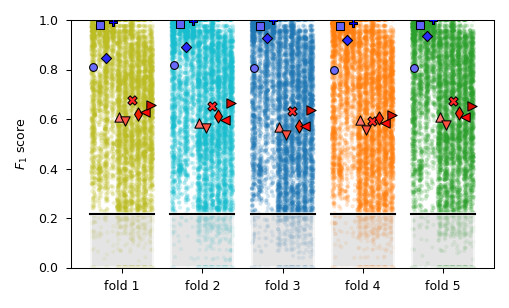

In [ ]:
strip_folds(summary_kfold, splits_kfold, "fold", "method", "2in2col", marker_colors, strip_colors, include_legend=False)

plt.savefig(DATA_PATH + f"figures/Fig_F1_{partition_name}.pdf", bbox_inches='tight', dpi=300)
plt.savefig(DATA_PATH + f"figures/Fig_F1_{partition_name}.png", bbox_inches='tight', dpi=300)

# Clustering folds

In [ ]:
partition_name = "clustering_folds"
splits_cfold = pd.read_csv(f"{DATA_PATH}data/{partition_name}_split.csv", index_col="id")
summary_cfold = pd.read_pickle(DATA_PATH + f"results/summary_{partition_name}.pkl")

/tmp/ipykernel_267789/1071901858.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"fold {int(v+1)}" for v in tt_plot[xx].tolist()])


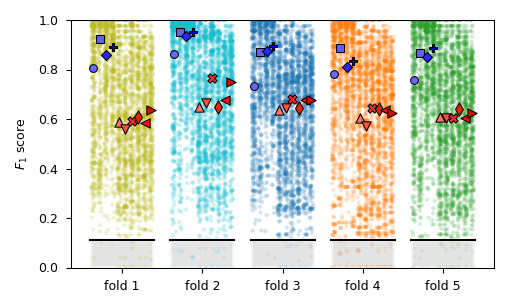

In [ ]:
strip_folds(summary_cfold, splits_cfold, "fold", "method", "2in2col", marker_colors, strip_colors, include_legend=False)

plt.savefig(DATA_PATH + f"figures/Fig_F1_{partition_name}.pdf", bbox_inches='tight', dpi=300)
plt.savefig(DATA_PATH + f"figures/Fig_F1_{partition_name}.png", bbox_inches='tight', dpi=300)

# Family folds

In [ ]:
partition_name = "fam_folds"
splits_ffold = pd.read_csv(f"{DATA_PATH}data/{partition_name}_split.csv", index_col="id")
summary_ffold = pd.read_pickle(DATA_PATH + f"results/summary_{partition_name}.pkl")

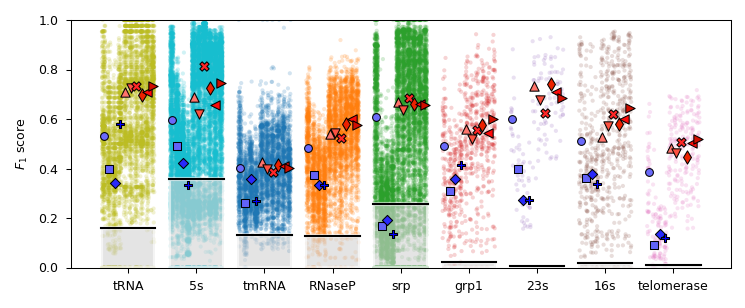

In [ ]:
sorted_families = ['tRNA', '5s', 'tmRNA', 'RNaseP', 'srp', 'grp1', '23s', '16s', 'telomerase'] # from RNA-LLM paper

strip_folds(summary_ffold, splits_ffold, "family", "method", "2x3in2col", marker_colors, strip_colors, include_legend=False, fam_order=sorted_families)

plt.savefig(DATA_PATH + f"figures/Fig_F1_{partition_name}.pdf", bbox_inches='tight', dpi=300)
plt.savefig(DATA_PATH + f"figures/Fig_F1_{partition_name}.png", bbox_inches='tight', dpi=300)

# Human learned folds

In [ ]:
partition_name = "hl_folds"
splits_hlfold = pd.read_csv(f"{DATA_PATH}data/{partition_name}_split.csv", index_col="id")
summary_hlfold = pd.read_pickle(DATA_PATH + f"results/summary_{partition_name}.pkl")

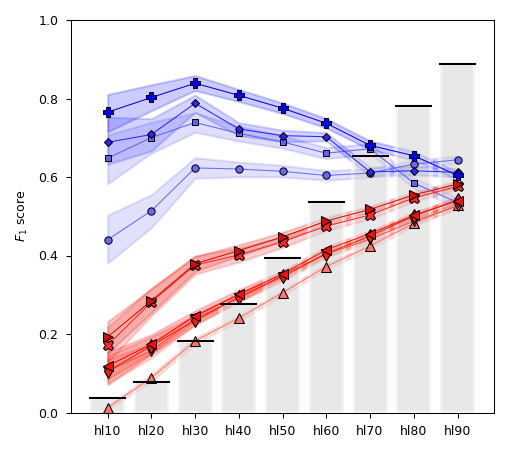

In [ ]:
#plt.figure(figsize=(10, 6))
#fig_size == "2in2col":
fig_width1col = 6.75/2

fig_height = 3.0

fig, ax = plt.subplots(figsize=(fig_width1col, fig_height), dpi=150)
plt.rcParams.update({'font.size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

for i, method in enumerate(summary_hlfold.method.unique()):
    sns.lineplot(
        data=summary_hlfold[summary_hlfold["method"] == method],
        x="fold", y="f1", label=method,
        marker=mmarkers[i],
        markersize=marker_sizes[i],
        markeredgecolor='black',
        markeredgewidth=0.5,
        color=marker_colors[i],
        linewidth=0.5
    )

test = splits_hlfold.loc[splits_hlfold['partition']=='test'].groupby(['fold_name']).count()
train = splits_hlfold.loc[splits_hlfold['partition']=='train'].groupby(['fold_name']).count()
tt = (test/(test+train))
filtered_folds = [f'hl{i}' for i in range(10, 100, 10)]
tt_filtered = tt[tt.index.isin(filtered_folds)]
ax = sns.barplot(data=tt_filtered, x=tt_filtered.index, y='partition', edgecolor = 'w', facecolor='lightgrey',
                 linewidth=2, err_kws={'color': 'none', 'linewidth': 0}, alpha=0.5, zorder=1)
for bar in ax.patches:
    x = bar.get_x()
    w = bar.get_width()
    h = bar.get_height()
    plt.plot([x, x + w], [h, h], color='black', linewidth=1, zorder=2)

#plt.xticks(rotation=45, fontsize=font_size)
plt.xticks(fontsize=font_size)
#plt.ylabel("$F_1$ score and test to train proportion", fontsize=font_size)
plt.ylabel("$F_1$ score", fontsize=font_size)
plt.ylim(0,1)
plt.xlabel("")
plt.legend().remove()
plt.tight_layout()

plt.savefig(DATA_PATH + f"figures/Fig_F1_{partition_name}.pdf", bbox_inches='tight', dpi=300)
plt.savefig(DATA_PATH + f"figures/Fig_F1_{partition_name}.png", bbox_inches='tight', dpi=300)

# Similarity folds

In [ ]:
partition_name = "sim_folds"
splits_sfold = []
for f in os.listdir(f"{DATA_PATH}data/{partition_name}_split/"):
    split = pd.read_csv(f"{DATA_PATH}data/{partition_name}_split/{f}")
    split["similarity"] = f.split("_")[-1].split("-")[0]
    splits_sfold.append(split)
splits_sfold = pd.concat(splits_sfold)

summary2 = pd.read_pickle(DATA_PATH + "results/summary_sfold.pkl")
summary_sfold = summary2["summary_sfold"]
AUCsim = summary2["AUCsim"]

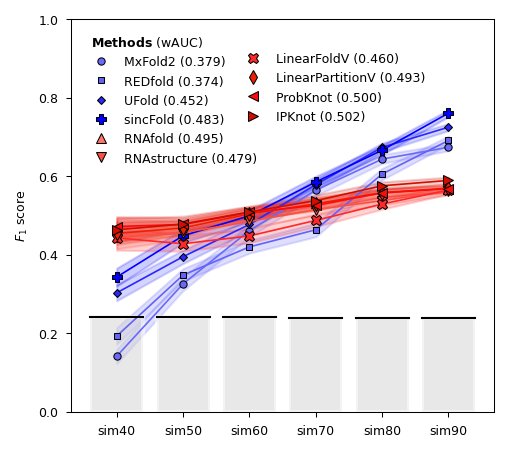

In [ ]:
#fig_size == "2in2col":
fig_width1col = 6.75/2
fig_height = 3.0

fig, ax = plt.subplots(figsize=(fig_width1col, fig_height), dpi=150)
plt.rcParams.update({'font.size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

for i, method in enumerate(summary_sfold.method.unique()):
    sns.lineplot(
        data=summary_sfold[summary_sfold["method"] == method],
        x="similarity",
        y="f1",
        label=method,
        marker=mmarkers[i],
        markersize=marker_sizes[i],
        color=marker_colors[i],
        markeredgecolor='black',
        markeredgewidth=0.5,
        linewidth=0.8
    )

test = splits_sfold.loc[splits_sfold['partition']=='test'].groupby(['similarity']).count()
train = splits_sfold.loc[splits_sfold['partition']=='train'].groupby(['similarity']).count()
tt = (test/(test+train))

tt_filtered = tt[tt.index != 'sim30']
ax = sns.barplot(data=tt_filtered, x=tt_filtered.index, y='partition', edgecolor = 'w',
                 facecolor='lightgrey', linewidth=2, err_kws={'color': 'none', 'linewidth': 0},
                 alpha=0.5, zorder=1)

for bar in ax.patches:
    x = bar.get_x()
    w = bar.get_width()
    h = bar.get_height()
    plt.plot([x, x + w], [h, h], color='black', linewidth=1, zorder=2)
    plt.tight_layout()


#plt.xticks(rotation=45, fontsize=font_size)
plt.xticks(fontsize=font_size)
#plt.ylabel("F1 score and test to train proportion", fontsize=font_size)
plt.ylabel("$F_1$ score", fontsize=font_size)
plt.ylim(0,1)
#plt.title("sim-folds")
plt.xlabel("")

methods = list(summary_sfold.method.unique())
handles = []
labels = []
for i, method in enumerate(methods):
    wauc = AUCsim.loc[method, "wAUC"] if method in AUCsim.index else float("nan")
    labels.append(f"{method} ({wauc:0.3f})")
    handles.append(
        Line2D([0], [0],
               marker=mmarkers[i % len(mmarkers)],
               color='w',
               markerfacecolor=marker_colors[i % len(marker_colors)],
               markeredgecolor='black',
               markeredgewidth=0.5,
               markersize=marker_sizes[i],
               linestyle='')
    )

# remove any existing legends
if ax.get_legend() is not None:
    ax.get_legend().remove()
for lg in list(fig.legends):
    lg.remove()

# split the handles/labels into two groups
leg1 = fig.legend(handles[:6], labels[:6],
                  title=r"$\mathbf{Methods}$ (wAUC)",
                  loc='upper left',
                  bbox_to_anchor=(0.15, 0.95),
                  fontsize=font_size,
                  frameon=False,
                  ncol=1)
leg2 = fig.legend(handles[6:], labels[6:],
                  loc='upper left',
                  bbox_to_anchor=(0.45, 0.91),
                  fontsize=font_size,
                  frameon=False,
                  ncol=1)
leg1.set_zorder(10)
leg1.get_title().set_position((-25.5, 0))

plt.tight_layout()

plt.savefig(DATA_PATH + f"figures/Fig_F1_{partition_name}.pdf", bbox_inches='tight', dpi=300)
plt.savefig(DATA_PATH + f"figures/Fig_F1_{partition_name}.png", bbox_inches='tight', dpi=300)